In [88]:
# ============================================================
# PKM-AI: KLASIFIKASI TINGKAT KELAYAKAN HARGA (WORTH-IT SCORE)
# RUMAH MENGGUNAKAN MODEL MACHINE LEARNING
# Universitas Ciputra Surabaya
# ============================================================
# Paste this entire file into a Google Colab notebook cell-by-cell.
# Each section marked with ### CELL ### should be a separate Colab cell.
# ============================================================


### CELL 1 — INSTALL & IMPORT LIBRARIES ###

# All libraries below are pre-installed in Google Colab.
# No pip install needed unless running locally.

import os
import glob
import warnings
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [89]:
from google.colab import drive
drive.mount('/content/drive/')
print("✅ Google Drive mounted.")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
✅ Google Drive mounted.


In [90]:
### CELL 3 — CONFIGURATION ###

# ⚙️ Point this to your single combined CSV file in Google Drive
COMBINED_CSV_PATH = '/content/drive/My Drive/Survey PKM/Survey_Combined_MajorityVote.csv'  # ← change filename if needed

TARGET_COLUMN = 'Worth-it'
OUTPUT_DIR    = '/content/drive/My Drive/Survey PKM/'

In [93]:
### CELL 4 — STEP 1: DATA LOADING ###
# Load a single combined CSV file from Google Drive.

def load_csv(file_path, target_col):
    """
    Loads a single combined CSV file and validates the target column exists.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"❌ File not found: {file_path}\n"
            "Please check your COMBINED_CSV_PATH in Cell 3."
        )

    df = pd.read_csv(file_path)

    print(f"✅ Loaded: {os.path.basename(file_path)}")
    print(f"\n📊 Dataset shape: {df.shape}")
    print(f"   Total rows   : {len(df)}")
    print(f"   Total columns: {len(df.columns)}")

    if target_col not in df.columns:
        raise KeyError(
            f"❌ Target column '{target_col}' not found.\n"
            f"   Available columns: {df.columns.tolist()}"
        )

    print(f"\n🎯 Target distribution:\n{df[target_col].value_counts()}")

    return df


df = load_csv(COMBINED_CSV_PATH, TARGET_COLUMN)
print("\n📋 First 5 rows:")
df.head()

✅ Loaded: Survey_Combined_MajorityVote.csv

📊 Dataset shape: (248, 29)
   Total rows   : 248
   Total columns: 29

🎯 Target distribution:
Worth-it
Not Worth-It    127
Worth-It        121
Name: count, dtype: int64

📋 First 5 rows:


,URL,Wilayah,Kecamatan,Luas Tanah (m2),Luas Bangunan (m2),Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Jual,Terjual/Belum,...,Dekat Sekolah,Dekat Puskesmas/RS,Dekat Mall,Dekat Tempat Ibadah,Dekat Makam,Dekat Club House,Dekat Jalan Raya Utama,Worth-it,Votes_WorthIt,Votes_NotWorthIt
0,https://www.99.co/id/properti/rumah-dijual-650...,Timur,Rungkut,100,60,2,1,1.0,"Rp650,000,000",Belum,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,Worth-It,8,2
1,https://www.99.co/id/properti/rumah-dijual-525...,Timur,Gunung Anyar,50,35,2,1,1.0,"Rp525,000,000",Belum,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,Not Worth-It,4,6
2,https://www.99.co/id/properti/rumah-dijual-625...,Timur,Rungkut,65,65,2,1,1.0,"Rp625,000,000",Belum,...,Y,Y,NaN,NaN,NaN,NaN,NaN,Not Worth-It,4,6
3,https://www.99.co/id/properti/rumah-dijual-17m...,Barat,Dukuh Pakis,460,350,5,3,1.0,"Rp17,000,000,000",Belum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Worth-It,3,7
4,https://www.99.co/id/properti/rumah-dijual-1mi...,Timur,Rungkut,100,120,3,2,1.0,"Rp1,100,000,000",Belum,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,Worth-It,7,3


In [94]:
### CELL 5 — DATA EXPLORATION ###

print("=" * 50)
print("📈 DATASET OVERVIEW")
print("=" * 50)
print(f"\nShape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nTarget value counts:\n{df[TARGET_COLUMN].value_counts()}")
print(f"\nBasic stats:\n{df.describe()}")

📈 DATASET OVERVIEW

Shape: (248, 29)

Column dtypes:
URL                               object
Wilayah                           object
Kecamatan                         object
Luas Tanah (m2)                    int64
Luas Bangunan (m2)                 int64
Jumlah Kamar                       int64
Jumlah Kamar Mandi                 int64
Tingkat/Lantai                   float64
Harga Jual                        object
Terjual/Belum                     object
Arah Hadap Rumah                  object
Posisi Rumah                      object
Lebar Jalan Depan Rumah (ROW)     object
Carport                           object
Fasilitas Tambahan               float64
Siap Huni \n(Y/N)                 object
Furnish \n(Y/N)                   object
Watt Listrik                      object
Dekat Pasar                       object
Dekat Sekolah                     object
Dekat Puskesmas/RS                object
Dekat Mall                        object
Dekat Tempat Ibadah               object
Deka

In [95]:
### CELL 6 — STEP 2: DATA PREPROCESSING ###

def preprocess_data(df, target_col):
    """
    Full preprocessing pipeline:
    - Drops non-feature columns (source_file, URLs, IDs)
    - Separates features (X) and target (y)
    - Identifies numeric vs categorical columns
    - Encodes target label
    - Returns X, y, feature_columns, label_encoder, categorical_cols, numeric_cols
    """

    # --- Drop utility/tracking columns that are NOT features ---
    cols_to_drop = ['source_file']

    # Auto-detect URL columns (not useful as features)
    for col in df.columns:
        if col.lower() in ['url', 'link', 'id', 'no', 'nomor']:
            cols_to_drop.append(col)
        elif df[col].dtype == object and df[col].str.startswith('http', na=False).mean() > 0.5:
            cols_to_drop.append(col)

    cols_to_drop = [c for c in cols_to_drop if c in df.columns and c != target_col]
    print(f"🗑️  Dropping non-feature columns: {cols_to_drop}")
    df_clean = df.drop(columns=cols_to_drop, errors='ignore').copy()

    # --- Separate features and target ---
    X = df_clean.drop(columns=[target_col])
    y_raw = df_clean[target_col].copy()

    feature_columns = X.columns.tolist()
    print(f"\n📌 Feature columns ({len(feature_columns)}): {feature_columns}")

    # --- Encode target label ---
    # LabelEncoder maps: "Not Worth It" → 0, "Worth It" → 1 (alphabetical)
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw.astype(str).str.strip())
    print(f"\n🏷️  Label encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

    # --- Identify column types ---
    numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    # ✅ Fix mixed types: convert categorical cols to string (NaN → stays NaN for imputer)
    for col in categorical_cols:
        X[col] = X[col].where(X[col].isna(), X[col].astype(str))

    print(f"\n🔢 Numeric columns ({len(numeric_cols)}): {numeric_cols}")
    print(f"🔤 Categorical columns ({len(categorical_cols)}): {categorical_cols}")

    return X, y, feature_columns, label_encoder, numeric_cols, categorical_cols


X, y, feature_columns, label_encoder, numeric_cols, categorical_cols = preprocess_data(df, TARGET_COLUMN)

print(f"\n✅ Preprocessing complete.")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   Class distribution: {dict(zip(label_encoder.classes_, np.bincount(y)))}")

🗑️  Dropping non-feature columns: ['URL']

📌 Feature columns (27): ['Wilayah', 'Kecamatan', 'Luas Tanah (m2)', 'Luas Bangunan (m2)', 'Jumlah Kamar', 'Jumlah Kamar Mandi', 'Tingkat/Lantai', 'Harga Jual', 'Terjual/Belum', 'Arah Hadap Rumah', 'Posisi Rumah', 'Lebar Jalan Depan Rumah (ROW)', 'Carport', 'Fasilitas Tambahan', 'Siap Huni \n(Y/N)', 'Furnish \n(Y/N)', 'Watt Listrik', 'Dekat Pasar', 'Dekat Sekolah', 'Dekat Puskesmas/RS', 'Dekat Mall', 'Dekat Tempat Ibadah', 'Dekat Makam', 'Dekat Club House', 'Dekat Jalan Raya Utama', 'Votes_WorthIt', 'Votes_NotWorthIt']

🏷️  Label encoding: {'Not Worth-It': np.int64(0), 'Worth-It': np.int64(1)}

🔢 Numeric columns (8): ['Luas Tanah (m2)', 'Luas Bangunan (m2)', 'Jumlah Kamar', 'Jumlah Kamar Mandi', 'Tingkat/Lantai', 'Fasilitas Tambahan', 'Votes_WorthIt', 'Votes_NotWorthIt']
🔤 Categorical columns (19): ['Wilayah', 'Kecamatan', 'Harga Jual', 'Terjual/Belum', 'Arah Hadap Rumah', 'Posisi Rumah', 'Lebar Jalan Depan Rumah (ROW)', 'Carport', 'Siap Huni \

In [97]:

### CELL 7 — BUILD PREPROCESSING PIPELINES ###

def build_preprocessor(numeric_cols, categorical_cols):
    """
    Builds a ColumnTransformer that:
    - Imputes and scales numeric columns
    - Imputes and one-hot-encodes categorical columns

    NOTE: Scaling is included in the pipeline for ALL models.
    For SVM and KNN, this is essential.
    For DT and LR, it does not harm performance.
    Fitting happens ONLY on training data (no data leakage).
    """

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),   # robust to outliers
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    transformers = []
    if numeric_cols:
        transformers.append(('num', numeric_transformer, numeric_cols))
    if categorical_cols:
        transformers.append(('cat', categorical_transformer, categorical_cols))

    preprocessor = ColumnTransformer(transformers=transformers)
    return preprocessor


preprocessor = build_preprocessor(numeric_cols, categorical_cols)
print("✅ Preprocessor pipeline built.")
print("   ↳ Numeric: Median Imputation → StandardScaler")
print("   ↳ Categorical: Mode Imputation → OneHotEncoder")

✅ Preprocessor pipeline built.
   ↳ Numeric: Median Imputation → StandardScaler
   ↳ Categorical: Mode Imputation → OneHotEncoder


In [98]:
### CELL 8 — STEP 3: TRAIN/TEST SPLIT + MODEL TRAINING ###

# --- Stratified 80/20 split (preserves class ratio — critical for small datasets) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # ensures balanced class distribution in both splits
)

print(f"✅ Stratified split complete.")
print(f"   Train size: {len(X_train)} rows")
print(f"   Test  size: {len(X_test)} rows")
print(f"   Train class distribution: {dict(zip(label_encoder.classes_, np.bincount(y_train)))}")
print(f"   Test  class distribution: {dict(zip(label_encoder.classes_, np.bincount(y_test)))}")

✅ Stratified split complete.
   Train size: 198 rows
   Test  size: 50 rows
   Train class distribution: {'Not Worth-It': np.int64(101), 'Worth-It': np.int64(97)}
   Test  class distribution: {'Not Worth-It': np.int64(26), 'Worth-It': np.int64(24)}


In [99]:
### CELL 9 — DEFINE ALL 4 MODELS ###

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# ✅ Use the preprocessor built in Cell 7 (handles numeric + categorical correctly)
models = {
    "Logistic Regression": Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Random Forest": Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),

    "Decision Tree": Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),

    "SVM": Pipeline([
        ('preprocessor', preprocessor),
        ('model', SVC(kernel='rbf', random_state=42))
    ])
}

print("✅ All 4 models defined as Pipelines:")
for name in models:
    print(f"   - {name}")

✅ All 4 models defined as Pipelines:
   - Logistic Regression
   - Random Forest
   - Decision Tree
   - SVM


In [100]:
### CELL 10 — CROSS-VALIDATION + TEST EVALUATION ###

def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test, cv_folds=5):
    """
    Trains a model pipeline and evaluates it using:
    1. 5-Fold Stratified Cross-Validation (on training data)
    2. Hold-out test set evaluation

    Returns a results dictionary with all metrics.

    Why F1-score?
    F1-score is the harmonic mean of Precision and Recall.
    For a binary "Worth It / Not Worth It" classification with potentially
    imbalanced classes (common in small labeled datasets), F1-score is more
    informative than raw accuracy, which can be misleading when one class
    dominates. F1 penalizes models that sacrifice recall for precision or vice versa.
    """

    print(f"\n{'='*55}")
    print(f"🔍 Evaluating: {name}")
    print(f"{'='*55}")

    # --- 5-Fold Stratified Cross-Validation ---
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

    cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=skf,
    scoring=cv_scoring,
    return_train_score=False,
    error_score='raise',   # ← add this
    n_jobs=-1
    )

    cv_accuracy  = cv_results['test_accuracy'].mean()
    cv_precision = cv_results['test_precision_weighted'].mean()
    cv_recall    = cv_results['test_recall_weighted'].mean()
    cv_f1        = cv_results['test_f1_weighted'].mean()

    print(f"\n📊 Cross-Validation ({cv_folds}-Fold) Results:")
    print(f"   Accuracy : {cv_accuracy:.4f} ± {cv_results['test_accuracy'].std():.4f}")
    print(f"   Precision: {cv_precision:.4f} ± {cv_results['test_precision_weighted'].std():.4f}")
    print(f"   Recall   : {cv_recall:.4f} ± {cv_results['test_recall_weighted'].std():.4f}")
    print(f"   F1-Score : {cv_f1:.4f} ± {cv_results['test_f1_weighted'].std():.4f}")

    # --- Fit on FULL training set ---
    pipeline.fit(X_train, y_train)

    # --- Evaluate on hold-out test set ---
    y_pred = pipeline.predict(X_test)

    test_accuracy  = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    test_recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    test_f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm             = confusion_matrix(y_test, y_pred)

    print(f"\n🧪 Test Set Results:")
    print(f"   Accuracy : {test_accuracy:.4f}")
    print(f"   Precision: {test_precision:.4f}")
    print(f"   Recall   : {test_recall:.4f}")
    print(f"   F1-Score : {test_f1:.4f}")
    present_labels = np.unique(np.concatenate([y_test, y_pred]))
    present_target_names = label_encoder.inverse_transform(present_labels)
    print(f"\n📋 Classification Report:\n{classification_report(y_test, y_pred, labels=present_labels, target_names=present_target_names)}")
    print(f"\n🔲 Confusion Matrix:\n{cm}")

    return {
        'name': name,
        'pipeline': pipeline,
        'cv_accuracy': cv_accuracy,
        'cv_precision': cv_precision,
        'cv_recall': cv_recall,
        'cv_f1': cv_f1,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'confusion_matrix': cm,
        'y_pred': y_pred
    }


# --- Run evaluation for all 4 models ---
results = {}
for model_name, pipeline in models.items():
    results[model_name] = evaluate_model(
        model_name, pipeline,
        X_train, y_train,
        X_test, y_test,
        cv_folds=5
    )

print("\n\n✅ All models evaluated.")




🔍 Evaluating: Logistic Regression

📊 Cross-Validation (5-Fold) Results:
   Accuracy : 0.9394 ± 0.0256
   Precision: 0.9460 ± 0.0199
   Recall   : 0.9394 ± 0.0256
   F1-Score : 0.9391 ± 0.0259

🧪 Test Set Results:
   Accuracy : 0.9600
   Precision: 0.9600
   Recall   : 0.9600
   F1-Score : 0.9600

📋 Classification Report:
              precision    recall  f1-score   support

Not Worth-It       0.96      0.96      0.96        26
    Worth-It       0.96      0.96      0.96        24

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50


🔲 Confusion Matrix:
[[25  1]
 [ 1 23]]

🔍 Evaluating: Random Forest

📊 Cross-Validation (5-Fold) Results:
   Accuracy : 0.9596 ± 0.0260
   Precision: 0.9637 ± 0.0227
   Recall   : 0.9596 ± 0.0260
   F1-Score : 0.9594 ± 0.0262

🧪 Test Set Results:
   Accuracy : 0.9000
   Precision: 0.9054
   Recall   : 0.9000
   F1-Score : 0.8994

📋 Classification

In [101]:

### CELL 11 — STEP 4: MODEL COMPARISON TABLE ###

def display_comparison(results, label_encoder):
    """
    Displays a formatted comparison table of all models.
    Selects the best model based on Cross-Validation F1-Score.

    CV F1 is used (not test F1) because it is more reliable on small datasets
    — it averages performance over 5 different train/val splits, reducing
    the influence of any single random split.
    """

    print("\n" + "="*75)
    print("📊 MODEL COMPARISON TABLE")
    print("="*75)

    rows = []
    for name, r in results.items():
        rows.append({
            'Model': name,
            'CV Accuracy': f"{r['cv_accuracy']:.4f}",
            'CV Precision': f"{r['cv_precision']:.4f}",
            'CV Recall': f"{r['cv_recall']:.4f}",
            'CV F1-Score': f"{r['cv_f1']:.4f}",
            'Test Accuracy': f"{r['test_accuracy']:.4f}",
            'Test F1-Score': f"{r['test_f1']:.4f}",
        })

    comparison_df = pd.DataFrame(rows)
    print(comparison_df.to_string(index=False))

    # --- Select best model based on CV F1-Score ---
    best_name = max(results, key=lambda k: results[k]['cv_f1'])
    best_result = results[best_name]

    print(f"\n{'='*75}")
    print(f"🏆 BEST MODEL SELECTED: {best_name}")
    print(f"   CV F1-Score  : {best_result['cv_f1']:.4f}")
    print(f"   Test F1-Score: {best_result['test_f1']:.4f}")
    print(f"   Test Accuracy: {best_result['test_accuracy']:.4f}")
    print(f"\n💡 Why F1-Score for model selection?")
    print(f"   F1-Score balances Precision and Recall.")
    print(f"   For 'Worth It / Not Worth It' classification with small,")
    print(f"   potentially imbalanced labeled data (n=248), accuracy alone")
    print(f"   can be misleading. F1-Score penalizes models that sacrifice")
    print(f"   either false positives or false negatives.")
    print(f"{'='*75}")

    return best_name, best_result, comparison_df


best_name, best_result, comparison_df = display_comparison(results, label_encoder)


📊 MODEL COMPARISON TABLE
              Model CV Accuracy CV Precision CV Recall CV F1-Score Test Accuracy Test F1-Score
Logistic Regression      0.9394       0.9460    0.9394      0.9391        0.9600        0.9600
      Random Forest      0.9596       0.9637    0.9596      0.9594        0.9000        0.8994
      Decision Tree      0.9597       0.9621    0.9597      0.9597        0.9200        0.9192
                SVM      0.9394       0.9407    0.9394      0.9393        0.9800        0.9800

🏆 BEST MODEL SELECTED: Decision Tree
   CV F1-Score  : 0.9597
   Test F1-Score: 0.9192
   Test Accuracy: 0.9200

💡 Why F1-Score for model selection?
   F1-Score balances Precision and Recall.
   For 'Worth It / Not Worth It' classification with small,
   potentially imbalanced labeled data (n=248), accuracy alone
   can be misleading. F1-Score penalizes models that sacrifice
   either false positives or false negatives.


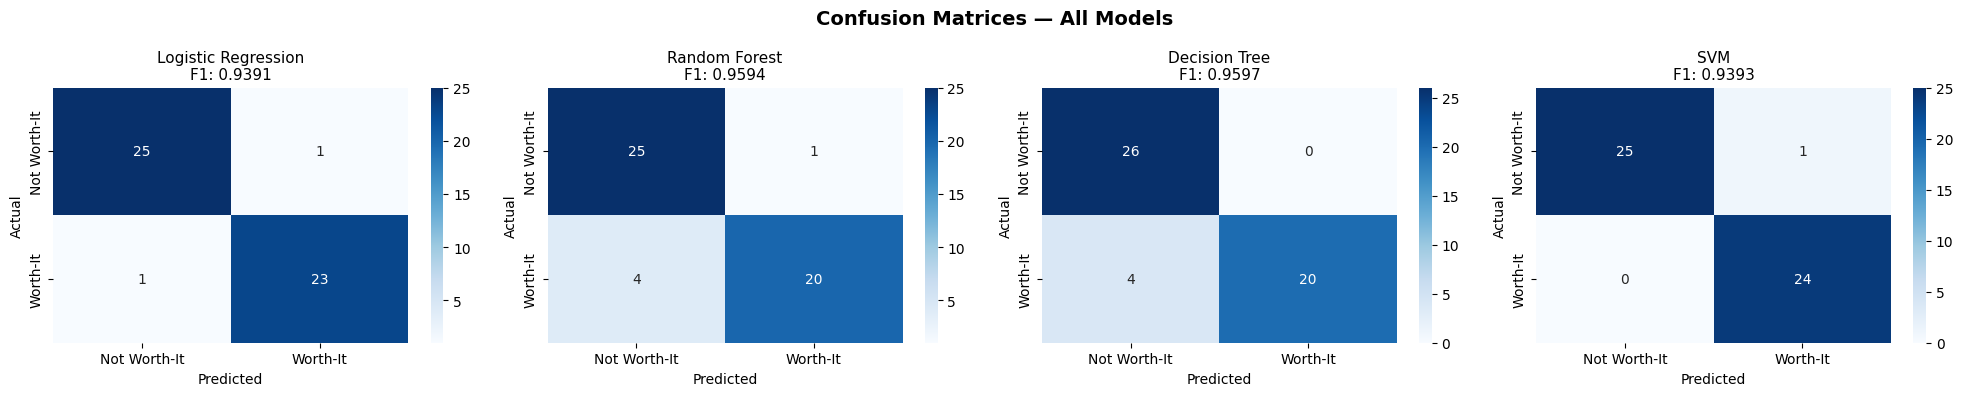

✅ Confusion matrices saved.


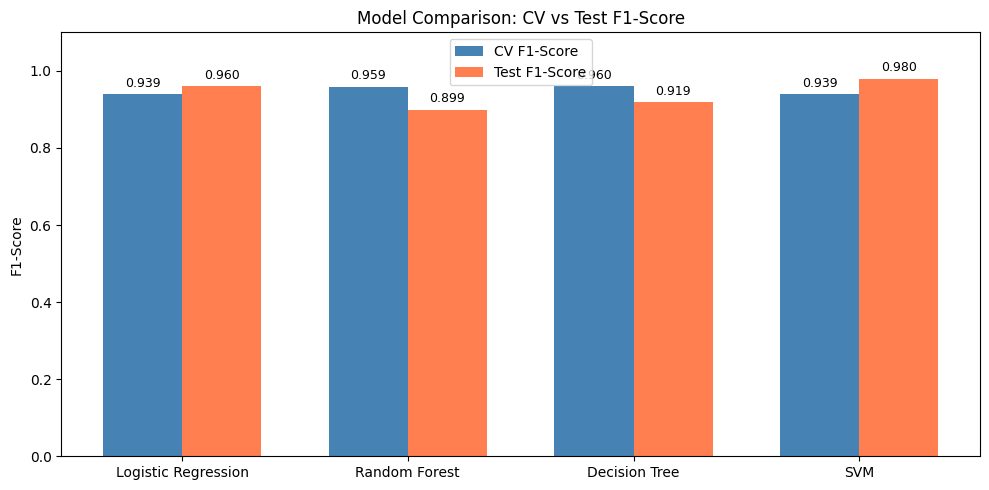

✅ Comparison bar chart saved.


In [102]:
### CELL 12 — CONFUSION MATRIX VISUALIZATION ###

def plot_confusion_matrices(results, label_encoder):
    """Plots confusion matrices for all 4 models side-by-side."""

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

    class_names = label_encoder.classes_

    for ax, (name, r) in zip(axes, results.items()):
        cm = r['confusion_matrix']
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax
        )
        ax.set_title(f"{name}\nF1: {r['cv_f1']:.4f}", fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Confusion matrices saved.")


def plot_model_comparison_bar(results):
    """Bar chart comparing CV F1-scores across all models."""

    names = list(results.keys())
    cv_f1s = [results[n]['cv_f1'] for n in names]
    test_f1s = [results[n]['test_f1'] for n in names]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, cv_f1s, width, label='CV F1-Score', color='steelblue')
    bars2 = ax.bar(x + width/2, test_f1s, width, label='Test F1-Score', color='coral')

    ax.set_ylabel('F1-Score')
    ax.set_title('Model Comparison: CV vs Test F1-Score')
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.legend()
    ax.set_ylim(0, 1.1)

    for bar in bars1 + bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Comparison bar chart saved.")


plot_confusion_matrices(results, label_encoder)
plot_model_comparison_bar(results)


In [103]:
### CELL 13 — STEP 5: SAVE TRAINED COMPONENTS ###

def save_model_components(best_result, best_name, label_encoder,
                           feature_columns, numeric_cols, categorical_cols,
                           output_dir):
    """
    Saves all components needed for prediction:
    - best_model.pkl    : The full trained pipeline (preprocessor + classifier)
    - label_encoder.pkl : Maps predicted int → "Worth It" / "Not Worth It"
    - feature_columns.pkl : The exact column order expected at inference time
    - model_metadata.pkl  : Metadata for documentation

    The pipeline already includes the scaler internally (ColumnTransformer),
    so no separate scaler.pkl is needed. The pipeline handles preprocessing
    end-to-end.
    """

    best_pipeline = best_result['pipeline']

    # 1. Save the full trained pipeline (includes preprocessor + classifier)
    model_path = os.path.join(output_dir, 'best_model.pkl')
    joblib.dump(best_pipeline, model_path)
    print(f"✅ Saved: best_model.pkl  → {model_path}")

    # 2. Save the label encoder
    encoder_path = os.path.join(output_dir, 'label_encoder.pkl')
    joblib.dump(label_encoder, encoder_path)
    print(f"✅ Saved: label_encoder.pkl → {encoder_path}")

    # 3. Save feature column order
    feature_path = os.path.join(output_dir, 'feature_columns.pkl')
    joblib.dump(feature_columns, feature_path)
    print(f"✅ Saved: feature_columns.pkl → {feature_path}")

    # 4. Save metadata
    metadata = {
        'best_model_name': best_name,
        'cv_f1': best_result['cv_f1'],
        'test_f1': best_result['test_f1'],
        'test_accuracy': best_result['test_accuracy'],
        'feature_columns': feature_columns,
        'numeric_cols': numeric_cols,
        'categorical_cols': categorical_cols,
        'label_classes': label_encoder.classes_.tolist(),
    }
    meta_path = os.path.join(output_dir, 'model_metadata.pkl')
    joblib.dump(metadata, meta_path)
    print(f"✅ Saved: model_metadata.pkl → {meta_path}")

    # Also save comparison table as CSV for PKM report
    comparison_csv_path = os.path.join(output_dir, 'model_comparison.csv')
    comparison_df.to_csv(comparison_csv_path, index=False)
    print(f"✅ Saved: model_comparison.csv → {comparison_csv_path}")

    print(f"\n📦 All components saved to: {output_dir}")
    return model_path, encoder_path, feature_path


model_path, encoder_path, feature_path = save_model_components(
    best_result, best_name, label_encoder,
    feature_columns, numeric_cols, categorical_cols,
    OUTPUT_DIR
)

✅ Saved: best_model.pkl  → /content/drive/My Drive/Survey PKM/best_model.pkl
✅ Saved: label_encoder.pkl → /content/drive/My Drive/Survey PKM/label_encoder.pkl
✅ Saved: feature_columns.pkl → /content/drive/My Drive/Survey PKM/feature_columns.pkl
✅ Saved: model_metadata.pkl → /content/drive/My Drive/Survey PKM/model_metadata.pkl
✅ Saved: model_comparison.csv → /content/drive/My Drive/Survey PKM/model_comparison.csv

📦 All components saved to: /content/drive/My Drive/Survey PKM/


In [104]:
### CELL 14 — STEP 6: PREDICTION FUNCTION ###

def load_prediction_components(output_dir):
    """Loads all saved model components from disk."""
    pipeline      = joblib.load(os.path.join(output_dir, 'best_model.pkl'))
    label_encoder = joblib.load(os.path.join(output_dir, 'label_encoder.pkl'))
    feature_cols  = joblib.load(os.path.join(output_dir, 'feature_columns.pkl'))
    return pipeline, label_encoder, feature_cols


def predict_house(input_dict, pipeline=None, label_encoder=None, feature_cols=None, output_dir=OUTPUT_DIR):
    """
    Predicts whether a house is "Worth It" or "Not Worth It".

    Parameters
    ----------
    input_dict : dict
        A dictionary containing house features.
        Keys must match the feature columns used during training.
        Example:
        {
            'Wilayah': 'Timur',
            'Kecamatan': 'Rungkut',
            'Luas Tanah (m2)': 100,
            'Luas Bangunan (m2)': 120,
            'Jumlah Kamar': 3,
            'Jumlah Kamar Mandi': 2,
            'Tingkat/Lantai': 2,
            'Harga (juta)': 1500,
            'Tujuan/Beton': 'Beton',
            'Arah Hadap Rumah': 'Timur',
            'Fasilitas Rumah': 'Hook',
            'Lebar Jalan Depan Rumah (ROW)': 8,
        }

    Returns
    -------
    dict with keys:
        - 'prediction'   : "Worth It" or "Not Worth It"
        - 'confidence'   : float (0.0 – 1.0), probability of predicted class
        - 'probabilities': dict with probability for each class
    """

    # Load components if not passed directly
    if pipeline is None or label_encoder is None or feature_cols is None:
        pipeline, label_encoder, feature_cols = load_prediction_components(output_dir)

    # --- Build input DataFrame ---
    input_df = pd.DataFrame([input_dict])

    # Ensure all expected columns are present (fill missing with NaN for imputation)
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = np.nan

    # Ensure correct column order
    input_df = input_df[feature_cols]

    # --- Predict ---
    pred_encoded  = pipeline.predict(input_df)[0]
    pred_proba    = pipeline.predict_proba(input_df)[0]
    pred_label    = label_encoder.inverse_transform([pred_encoded])[0]
    confidence    = float(pred_proba[pred_encoded])

    prob_dict = {
        label_encoder.classes_[i]: round(float(p), 4)
        for i, p in enumerate(pred_proba)
    }

    result = {
        'prediction': pred_label,
        'confidence': round(confidence, 4),
        'probabilities': prob_dict
    }

    print(f"\n🏠 Prediction Result:")
    print(f"   Verdict     : {'✅ Worth It' if pred_label == 'Worth It' else '❌ Not Worth It'}")
    print(f"   Confidence  : {confidence:.2%}")
    print(f"   Probabilities: {prob_dict}")

    return result


# --- Example usage (edit values to match your actual columns) ---
example_house = {
    'Wilayah': 'Timur',
    'Kecamatan': 'Rungkut',
    'Luas Tanah (m2)': 100,
    'Luas Bangunan (m2)': 120,
    'Jumlah Kamar': 3,
    'Jumlah Kamar Mandi': 2,
    'Tingkat/Lantai': 2,
    'Harga (juta)': 1500,
    'Tujuan/Beton': 'Beton',
    'Arah Hadap Rumah': 'Timur',
    'Fasilitas Rumah': 'Hook',
    'Lebar Jalan Depan Rumah (ROW)': 8,
}

# Load saved components and predict
loaded_pipeline, loaded_le, loaded_features = load_prediction_components(OUTPUT_DIR)
prediction_result = predict_house(
    example_house,
    pipeline=loaded_pipeline,
    label_encoder=loaded_le,
    feature_cols=loaded_features
)



🏠 Prediction Result:
   Verdict     : ❌ Not Worth It
   Confidence  : 87.50%
   Probabilities: {'Not Worth-It': 0.875, 'Worth-It': 0.125}


In [105]:
### CELL 15 — SUMMARY PRINT ###

print("\n" + "="*60)
print("📝 PKM-AI EXPERIMENT SUMMARY")
print("="*60)
print(f"Dataset   : {len(df)} rows × {len(feature_columns)} features")
print(f"Train/Test: {len(X_train)} / {len(X_test)} rows")
print(f"CV Folds  : 5-Fold Stratified")
print()
for name, r in results.items():
    marker = "🏆" if name == best_name else "  "
    print(f"{marker} {name:<22} | CV F1: {r['cv_f1']:.4f} | Test F1: {r['test_f1']:.4f} | Test Acc: {r['test_accuracy']:.4f}")
print()
print(f"Best Model : {best_name}")
print(f"Saved to   : {OUTPUT_DIR}")
print("="*60)


📝 PKM-AI EXPERIMENT SUMMARY
Dataset   : 248 rows × 27 features
Train/Test: 198 / 50 rows
CV Folds  : 5-Fold Stratified

   Logistic Regression    | CV F1: 0.9391 | Test F1: 0.9600 | Test Acc: 0.9600
   Random Forest          | CV F1: 0.9594 | Test F1: 0.8994 | Test Acc: 0.9000
🏆 Decision Tree          | CV F1: 0.9597 | Test F1: 0.9192 | Test Acc: 0.9200
   SVM                    | CV F1: 0.9393 | Test F1: 0.9800 | Test Acc: 0.9800

Best Model : Decision Tree
Saved to   : /content/drive/My Drive/Survey PKM/
